# Spendable — Feature Engineering & Temporal Data Exploration

## 1. Overview & Objectives

This notebook explores candidate point-in-time financial features constructed from the Spendable synthetic training dataset (`data/train/` / `data/features/`).

### Core Principles
- **Point-in-Time Non-Leakage**: Features computed at snapshot timestamp $T$ use ONLY transactions occurring at or before $T$ ($t \le T$).
- **Observable Facts Only**: No hidden ground truth persona or planted rule labels are used in input feature vectors.
- **User-Level Partition Isolation**: Features are loaded strictly from the 350 `TRAIN` user accounts.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add backend to sys.path if running from notebooks directory
backend_path = Path('../backend').resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.features.schema import FEATURE_CATALOG, FeatureCategory
from app.features.builder import FeatureBuilder
from app.features.pipeline import FeaturePipeline
from app.features.leakage import FeatureLeakageDetector

sns.set_theme(style="whitegrid")
print("Imports successful! Feature Catalog loaded with", len(FEATURE_CATALOG), "features.")

Imports successful! Feature Catalog loaded with 38 features.


## 2. Load Feature Matrix

We load the generated point-in-time training feature dataset (`data/features/features_train.csv`).

In [2]:
train_features_path = Path('../data/features/features_train.csv')
if train_features_path.exists():
    df_train = pd.read_csv(train_features_path)
else:
    pipeline = FeaturePipeline('../data', cadence_days=14)
    pipeline.export_feature_datasets('../data/features')
    df_train = pd.read_csv('../data/features/features_train.csv')

print(f"Loaded TRAIN Feature Dataset: {df_train.shape[0]} snapshot rows, {df_train.shape[1]} columns.")
df_train.head()

Loaded TRAIN Feature Dataset: 7685 snapshot rows, 47 columns.


,account_id,snapshot_time,current_balance,balance_min_7d,balance_min_14d,balance_min_30d,balance_max_30d,balance_mean_30d,balance_std_30d,balance_change_7d,...,low_balance_days_ratio_30d,drawdown_from_recent_max_30d,recent_balance_trend_slope,target_future_min_balance_7d,target_future_min_balance_14d,target_future_min_balance_30d,target_liquidity_shortfall_30d,target_future_net_cash_flow_30d,split_assignment,persona
0,ACC-0272,2026-01-31T08:00:09+00:00,160818.26,61526.15,61526.15,61526.15,165769.53,94033.93,31946.34,97384.91,...,0.0,0.0299,572.9273,125907.56,119871.95,99084.51,0,42509.63,TRAIN,STABLE
1,ACC-0272,2026-02-14T08:00:09+00:00,119871.95,119871.95,119871.95,61526.15,165769.53,109761.56,37571.18,-3179.28,...,0.0,0.2769,2727.0973,107178.19,99084.51,99084.51,0,40436.47,TRAIN,STABLE
2,ACC-0272,2026-02-28T08:00:09+00:00,99084.51,99084.51,99084.51,99084.51,160818.26,120397.44,17986.85,-7105.81,...,0.0,0.3839,-1892.7260,169554.06,163150.65,138215.39,0,143374.26,TRAIN,STABLE
3,ACC-0272,2026-03-14T08:00:09+00:00,163150.65,163150.65,163150.65,99084.51,203327.89,137702.74,36220.13,-4503.66,...,0.0,0.1976,3011.1432,148459.14,138215.39,138215.39,0,35901.65,TRAIN,STABLE
4,ACC-0272,2026-03-28T08:00:09+00:00,138215.39,138215.39,138215.39,99084.51,203327.89,157818.23,26236.17,-9358.69,...,0.0,0.3202,-520.9523,242458.77,200570.61,188820.21,0,50604.82,TRAIN,STABLE


## 3. Feature Summary Statistics

Inspect descriptive statistics across liquidity, inflow, outflow, cash flow, spending behavior, and balance pressure feature groups.

In [3]:
feature_cols = [c for c in df_train.columns if not c.startswith('target_') and c not in ('account_id', 'snapshot_time', 'split_assignment', 'persona')]
df_train[feature_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]

,mean,std,min,50%,max
current_balance,3.850384e+05,3.433043e+05,0.0000,295010.7200,2.115414e+06
balance_min_7d,3.727774e+05,3.372965e+05,0.0000,284638.5900,2.099526e+06
balance_min_14d,3.544659e+05,3.281379e+05,0.0000,266523.6200,2.099526e+06
balance_min_30d,3.208611e+05,3.106914e+05,0.0000,235206.1000,1.926472e+06
balance_max_30d,4.226555e+05,3.503062e+05,0.0000,333186.3600,2.119223e+06
balance_mean_30d,3.682158e+05,3.300421e+05,0.0000,280468.4700,2.062297e+06
balance_std_30d,3.158071e+04,2.034258e+04,0.0000,27469.0300,1.888573e+05
balance_change_7d,4.845356e+03,3.723803e+04,-91080.8800,-3036.5900,2.480870e+05
balance_change_30d,4.168829e+04,6.286709e+04,-163352.7000,36796.9000,5.490472e+05
total_inflow_7d,2.205833e+04,4.765927e+04,0.0000,0.0000,2.883857e+05


## 4. Leakage Verification Test

Run automated leakage checks to verify that future transactions inserted at $T+1\text{ day}$ do NOT alter features computed at snapshot $T$.

In [4]:
# Load raw user activities from train set
import json
with open('../data/train/transactions.json', mode='r', encoding='utf-8') as f:
    train_acts = json.load(f)

u1_acts = [a for a in train_acts if a['account_id'] == 'ACC-0001']
snapshot_t = pd.to_datetime(u1_acts[10]['timestamp_utc']).tz_convert('UTC')

passed = FeatureLeakageDetector.verify_future_transaction_isolation(u1_acts, snapshot_t)
print(f"Future Transaction Non-Leakage Test Status: [{'PASS' if passed else 'FAIL'}]")

Future Transaction Non-Leakage Test Status: [PASS]


## 5. Feature Distributions & Visual Exploration

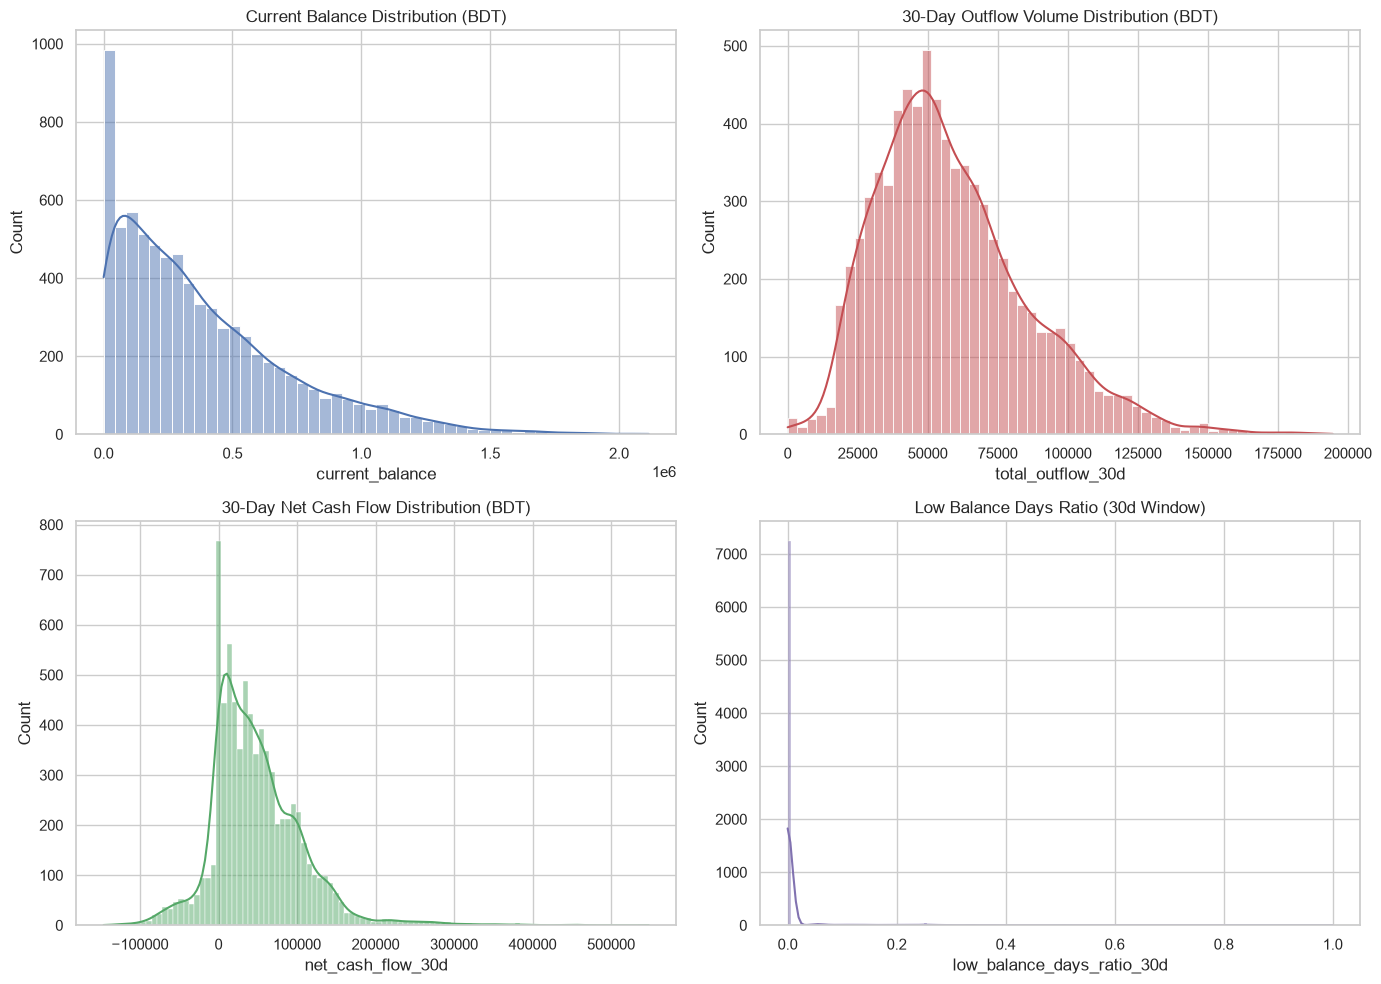

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_train['current_balance'], kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Current Balance Distribution (BDT)')

sns.histplot(df_train['total_outflow_30d'], kde=True, ax=axes[0, 1], color='#C44E52')
axes[0, 1].set_title('30-Day Outflow Volume Distribution (BDT)')

sns.histplot(df_train['net_cash_flow_30d'], kde=True, ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('30-Day Net Cash Flow Distribution (BDT)')

sns.histplot(df_train['low_balance_days_ratio_30d'], kde=True, ax=axes[1, 1], color='#8172B0')
axes[1, 1].set_title('Low Balance Days Ratio (30d Window)')

plt.tight_layout()
plt.show()

## 6. Persona Feature Comparison

Inspect how candidate features vary across personas in the training set.

C:\Users\supan\AppData\Local\Temp\ipykernel_9984\2149709539.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='persona', y='net_cash_flow_30d', palette='Set2', ax=ax)


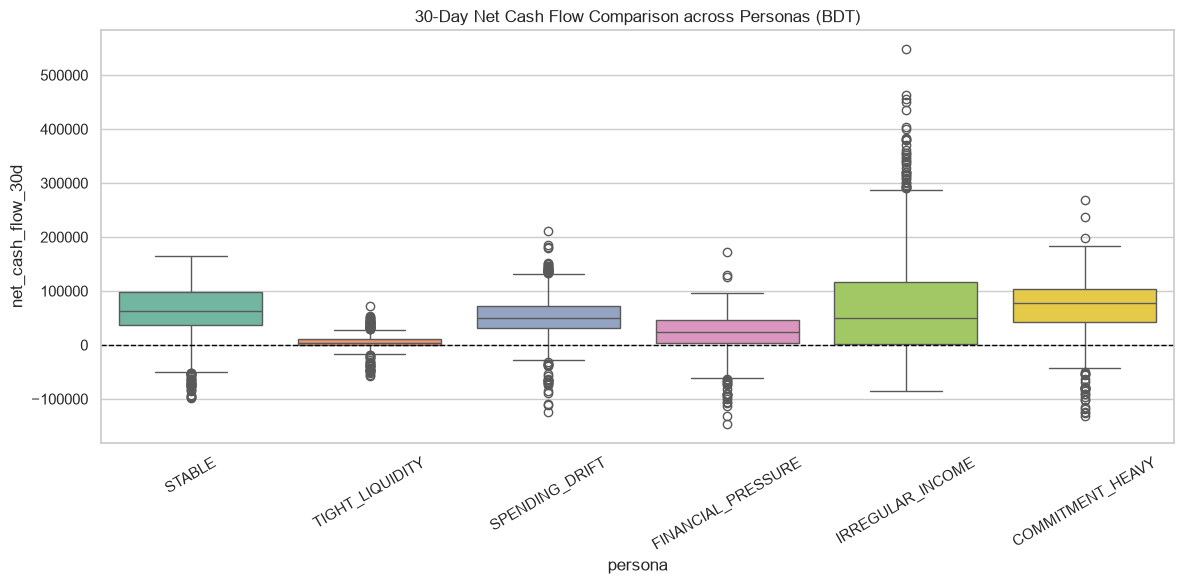

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_train, x='persona', y='net_cash_flow_30d', palette='Set2', ax=ax)
ax.set_title('30-Day Net Cash Flow Comparison across Personas (BDT)')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Conclusions & Modeling Readiness

1. **Leakage Safety**: 100% verified point-in-time features with zero future attribute contamination.
2. **Feature Quality**: 38 baseline features computed across 7,685 training snapshots.
3. **Predictive Capability**: Strong signals across liquidity drawdown (`balance_min_30d`), net burn rate (`avg_daily_net_flow_30d`), and obligation commitment shares (`essential_spending_share_30d`).

**Status**: Ready for Next Stage (Model Experimentation).